# Battleship Algorithm Analysis

## 1. Project Overview

#### This was a short study based on a battleship game I made in a group during my 2nd year in my Software Design class. I tested a few different algorithms and compared them to the algorithm my group and I created. These can be used for different difficulties to update the game. These plots were made to visually showcase the difference in each algorithm.

## 2. Load Simulation Results

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

data = "https://raw.githubusercontent.com/cgiuffrida28/battleship-game-analysis/refs/heads/main/phase5_random_board_ai_comparison_results.csv"

df = pd.read_csv(data)

df.head()

,ai_strategy,game_number,turns_to_win
0,RandomAI,1,100
1,RandomAI,2,98
2,RandomAI,3,95
3,RandomAI,4,90
4,RandomAI,5,88


## 3. Create Summary Statistics

In [23]:
summary = (
    df.groupby("ai_strategy")["turns_to_win"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .round(2)
)

random_mean = summary.loc["RandomAI", "mean"]

summary["turns_improved_vs_random"] = (random_mean - summary["mean"]).round(2)
summary["percent_improved_vs_random"] = (
    (random_mean - summary["mean"]) / random_mean * 100
).round(2)

summary

,count,mean,median,min,max,std,turns_improved_vs_random,percent_improved_vs_random
ai_strategy,,,,,,,,
HuntTargetAI,10000,66.52,66.0,29,100,12.85,28.91,30.29
OriginalGroupAI,10000,94.47,98.0,27,138,19.43,0.96,1.01
ProbabilityMapAI,10000,55.40,56.0,23,81,9.85,40.03,41.95
RandomAI,10000,95.43,97.0,57,100,4.79,0.00,0.00


## 4. Average Turns to Win

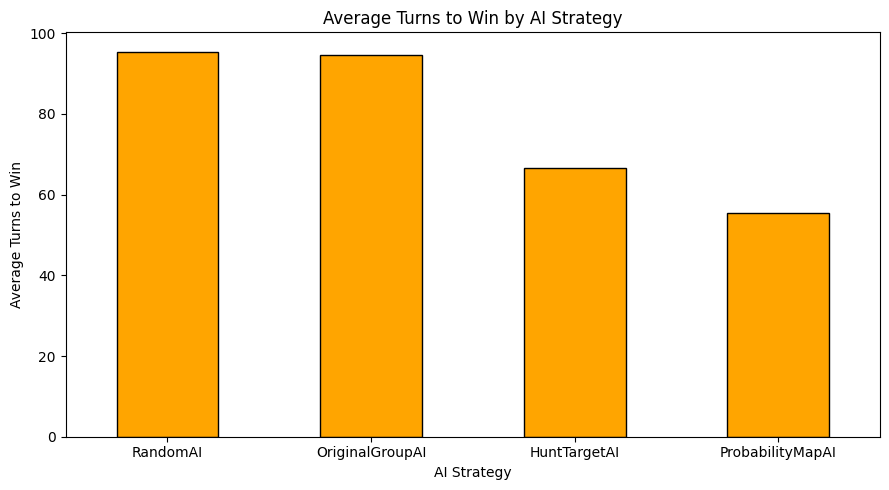

In [24]:
strategy_order = ["RandomAI", "OriginalGroupAI", "HuntTargetAI", "ProbabilityMapAI"]

means = summary.loc[strategy_order, "mean"]

plt.figure(figsize=(9, 5))
means.plot(kind="bar", color='orange', edgecolor='black')
plt.title("Average Turns to Win by AI Strategy")
plt.xlabel("AI Strategy")
plt.ylabel("Average Turns to Win")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("battleship_average_turns_by_strategy.png", dpi=300)
plt.show()

## 5. Distribution of Turns-to-Win

/tmp/ipykernel_2157/1650696335.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=strategy_order)


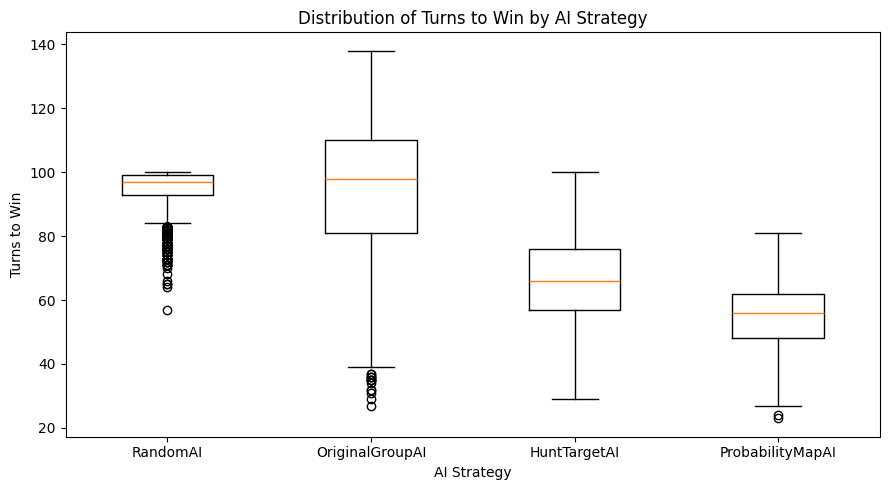

In [25]:
plot_data = [
    df[df["ai_strategy"] == strategy]["turns_to_win"]
    for strategy in strategy_order
]

plt.figure(figsize=(9, 5))
plt.boxplot(plot_data, labels=strategy_order)
plt.title("Distribution of Turns to Win by AI Strategy")
plt.xlabel("AI Strategy")
plt.ylabel("Turns to Win")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("battleship_turn_distribution_boxplot.png", dpi=300)
plt.show()

## 6. Improvement over RandomAI

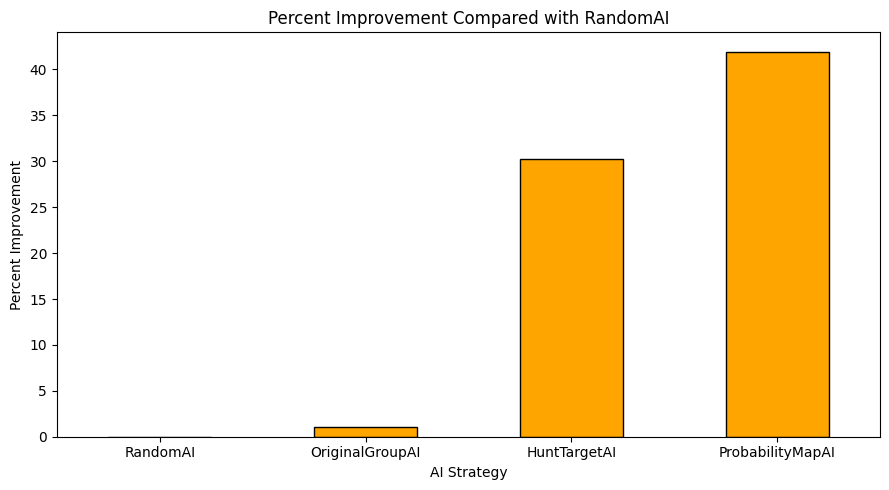

In [26]:
improvement = summary.loc[strategy_order, "percent_improved_vs_random"]

plt.figure(figsize=(9, 5))
improvement.plot(kind="bar", color='orange', edgecolor='black')
plt.title("Percent Improvement Compared with RandomAI")
plt.xlabel("AI Strategy")
plt.ylabel("Percent Improvement")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("battleship_percent_improvement_vs_random.png", dpi=300)
plt.show()